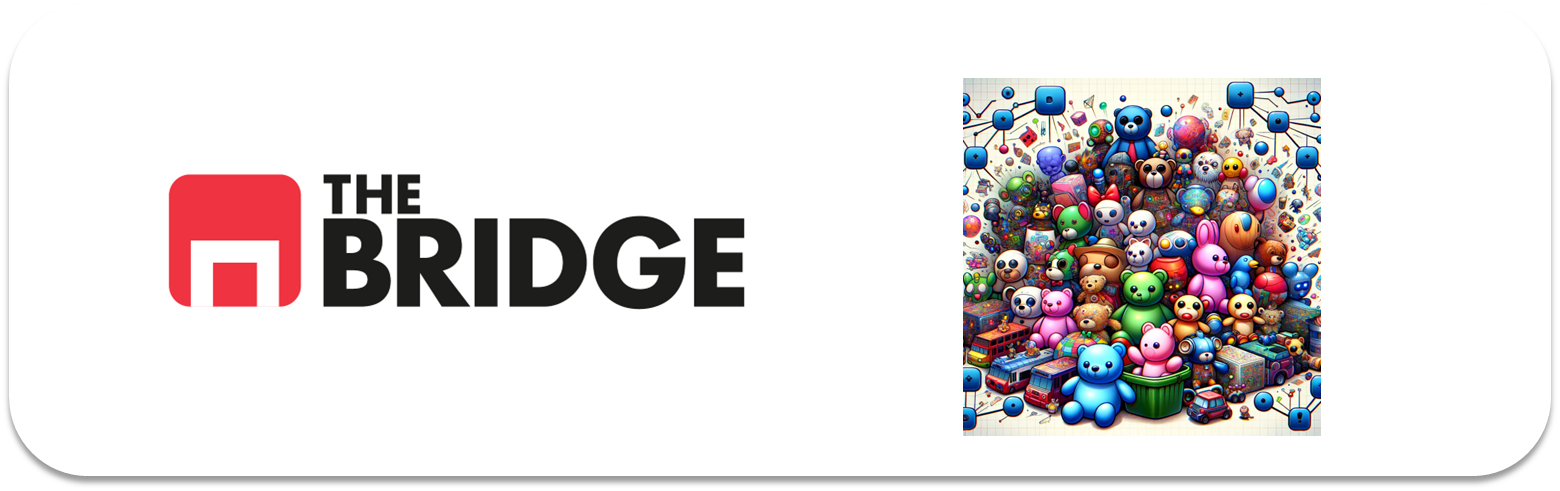

## PRACTICA OBLIGATORIA: **K-Means Clustering**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado sobre imágenes para practicar con el algoritmo k-means. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [60]:
#Importamos librerias:
import numpy as np
import pandas as pd
pd.options.mode.copy_on_write = True

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
np.random.seed(42)
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

## **#1**

Vamos a trabajar con un dataset también entre los "clásicos" (aunque a veces menos conocido) que es el de rostros Olivetti. Este dataset contiene 400 imágenes en escala de grises de 64 × 64 píxeles de rostros.   


Como en otros datasets de imágenes, estás están "aplanadas" de forma que cada pixel es una feature y por cada imagen hay $64\times 64 = 4096$ features.  

Se fotografiaron 40 personas diferentes (10 veces cada una) y esas fotografías se recogen en el dataset.  

La tarea habitual es entrenar un modelo que pueda predecir qué persona está representada en cada imagen, pero nosotros lo vamos a hacer de forma no supervisada. 



### #1.1


Carga el conjunto de datos usando la función `sklearn.datasets.fetch_olivetti_faces()`. Recuerda que se carga un "diccionario". Muestra su descripción acudiendo a la clave "DESCR".

In [9]:
#Importamos el dataset:
from sklearn.datasets import fetch_olivetti_faces
#Cargamos los datos:

faces=fetch_olivetti_faces() #shuffle=True, random_state=42

In [10]:
#Imprimimos la descripción
print(faces.DESCR)

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes              

In [11]:
faces.keys()

dict_keys(['data', 'images', 'target', 'DESCR'])

In [12]:
faces.target

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22,
       22, 22, 22, 22, 22

### #1.2 

Aunque no lo vas a usar hasta el final de la práctica, muestra el target. Luego cargalo todo en un mismo dataframe (tendrás que añadir el target) y obtén otro dataset con todas las imagenes reordenadas aleatoriamente (emplea por ejemplo el método `sample` del dataframe o el método que tú quieras)

In [13]:
#Sacamos los datos, las imágenes y el target:
data = faces.data
images = faces.images
target = faces.target

In [14]:
#Mostramos el target:
print(faces.target[:50]) #El número de persona (0-39)

[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3
 3 3 3 4 4 4 4 4 4 4 4 4 4]


In [ ]:
#Longitud
len(faces.data)

400

In [ ]:
#No esta aplanado (tensores)
faces.images

array([[[0.30991736, 0.3677686 , 0.41735536, ..., 0.37190083,
         0.3305785 , 0.30578512],
        [0.3429752 , 0.40495867, 0.43801653, ..., 0.37190083,
         0.338843  , 0.3140496 ],
        [0.3429752 , 0.41735536, 0.45041323, ..., 0.38016528,
         0.338843  , 0.29752067],
        ...,
        [0.21487603, 0.20661157, 0.2231405 , ..., 0.15289256,
         0.16528925, 0.17355372],
        [0.20247933, 0.2107438 , 0.2107438 , ..., 0.14876033,
         0.16115703, 0.16528925],
        [0.20247933, 0.20661157, 0.20247933, ..., 0.15289256,
         0.16115703, 0.1570248 ]],

       [[0.45454547, 0.47107437, 0.5123967 , ..., 0.19008264,
         0.18595041, 0.18595041],
        [0.446281  , 0.48347107, 0.5206612 , ..., 0.21487603,
         0.2107438 , 0.2107438 ],
        [0.49586776, 0.5165289 , 0.53305787, ..., 0.20247933,
         0.20661157, 0.20661157],
        ...,
        [0.77272725, 0.78099173, 0.7933884 , ..., 0.1446281 ,
         0.1446281 , 0.1446281 ],
        [0.7

In [25]:
df_caras = pd.DataFrame(faces.data, columns = [f"pixel_{i}" for i in range(4096)])
df_caras

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_4086,pixel_4087,pixel_4088,pixel_4089,pixel_4090,pixel_4091,pixel_4092,pixel_4093,pixel_4094,pixel_4095
0,0.309917,0.367769,0.417355,0.442149,0.528926,0.607438,0.657025,0.677686,0.690083,0.685950,...,0.665289,0.669421,0.652893,0.661157,0.475207,0.132231,0.148760,0.152893,0.161157,0.157025
1,0.454545,0.471074,0.512397,0.557851,0.595041,0.640496,0.681818,0.702479,0.710744,0.702479,...,0.136364,0.157025,0.136364,0.148760,0.152893,0.152893,0.152893,0.152893,0.152893,0.152893
2,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.074380,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893
3,0.198347,0.194215,0.194215,0.194215,0.190083,0.190083,0.243802,0.404959,0.483471,0.516529,...,0.652893,0.636364,0.657025,0.685950,0.727273,0.743802,0.764463,0.752066,0.752066,0.739669
4,0.500000,0.545455,0.582645,0.623967,0.648760,0.690083,0.694215,0.714876,0.723140,0.731405,...,0.190083,0.161157,0.177686,0.173554,0.177686,0.177686,0.177686,0.177686,0.173554,0.173554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.400826,0.495868,0.570248,0.632231,0.648760,0.640496,0.661157,0.636364,0.665289,0.698347,...,0.388430,0.396694,0.264463,0.099174,0.181818,0.243802,0.247934,0.161157,0.157025,0.136364
396,0.367769,0.367769,0.351240,0.301653,0.247934,0.247934,0.367769,0.512397,0.574380,0.628099,...,0.380165,0.334711,0.289256,0.285124,0.338843,0.404959,0.458678,0.487603,0.512397,0.549587
397,0.500000,0.533058,0.607438,0.628099,0.657025,0.632231,0.657025,0.669421,0.673554,0.702479,...,0.194215,0.148760,0.152893,0.161157,0.161157,0.173554,0.157025,0.177686,0.148760,0.190083
398,0.214876,0.219008,0.219008,0.223140,0.210744,0.202479,0.276859,0.400826,0.487603,0.549587,...,0.446281,0.392562,0.367769,0.409091,0.479339,0.524793,0.545455,0.574380,0.590909,0.603306


In [26]:
df_caras["target"]=faces.target
print(f"Dimensiones del dataset: {df_caras.shape}.")
#400 columnas, 

Dimensiones del dataset: (400, 4097).


In [27]:
#Creamos el dataset reordenado con sample:
df_caras_random = df_caras.sample(frac=1, random_state=42).reset_index(drop=True) #frac toma el 100% de los datos

In [30]:
#Pixel --> valores de 0 a 1 (escala de grises)
#Pixes del color --> cada punto es un vector

In [28]:
np.min(df_caras_random.describe().T["min"])

np.float64(0.0)

In [24]:
np.max(df_caras_random.describe().T["max"])

np.float64(1.0)

In [29]:
df_caras_random.target

0      20
1      28
2       3
3      21
4       9
       ..
395     7
396    10
397    27
398    34
399    10
Name: target, Length: 400, dtype: int64

### #1.3

Vamos a dividir en train y test, pero OJO RECUERDA QUE EN LOS PROBLEMAS NO SUPERVISADOS NO HAY SPLIT (porque no hay target), aquí lo hacemos para poder comparar posteriormente el clustering con la clasificación (ya que es uan práctica formativa).

Por tanto, divídelo en un conjunto de entrenamiento, un conjunto de validación y un conjunto de pruebas (80-10-10). Dado que el conjunto de datos es bastante pequeño, emplea un muestreo estratificado para asegurarse de que haya el mismo número de imágenes por persona en cada conjunto (estratificando por la columna que contenga el target)

NOTA: No hemos hecho hasta ahora la separación en tres sets, investiga por tu cuenta o bien haz primero un split 90-10 y luego otro split 89-11 sobre el de 80 (para que de los números aproximados), por ejemplo.

In [31]:
#OJO: Aquí no hay target, no es necesario hacer split
#Para no malgastar datos en validación se emplea la valdiación cruzada
from sklearn.model_selection import train_test_split

#Separamos el 80% para entrenamientos
#Es importante stratify para que ninguna persona se quede fuera del test de entrenamiento

train_set, temporal_set= train_test_split(df_caras_random, test_size=0.2, random_state=42, stratify=df_caras_random['target'])

In [32]:
#Comprobamos las dimensiones:
print(train_set.shape)
print(temporal_set.shape)

(320, 4097)
(80, 4097)


In [33]:
#Creamos los dataset de validación y test
val_set, test_set = train_test_split(temporal_set, test_size=0.50, random_state=42, stratify=temporal_set['target'])

In [34]:
print(val_set.shape)
print(test_set.shape)

(40, 4097)
(40, 4097)


### #1.4

Crea los pares X,y para train, validation y test.

In [35]:
#Creamos los pares:
#Datasets de Entrenamiento
X_train = train_set.drop('target', axis=1)
y_train = train_set['target']

#Datasets de Validación
X_val = val_set.drop('target', axis=1)
y_val = val_set['target']

#Datasets de Pruebas
X_test = test_set.drop('target', axis=1)
y_test = test_set['target']

Utiliza la siguiente función para visualizar alguna de las caras (observa que tienes que dar la X y la y, usa iloc en ambos datasets)

In [36]:
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

In [ ]:
y_train.iloc[:]

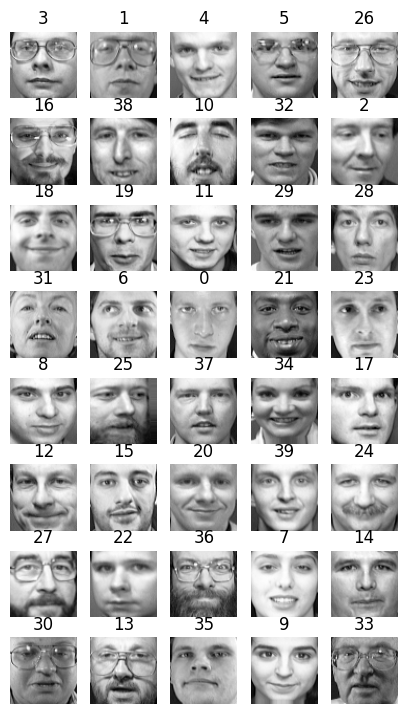

In [ ]:
#Pintamos todas las personas (40 en total)
plot_faces(X_test.values, y_test)

### #1.5

Para acelerar las cosas, reduciremos la dimensionalidad de los datos utilizando PCA (técnica que veremos en el siguiente sprint). Modifica la siguiente celda de forma que las X se correspondan con las que has utilizado en el ejercicio anterior.

In [ ]:
#Reducimos la dimensionalidad (número de características):
#Utiliza la proyección -- PCA - Principal components analysis
#Cambia el origen de coordenadas de los datos (maximiza la varianza y proyecta los datos) --> ejemplo sombra (pierdas información)
from sklearn.decomposition import PCA

pca = PCA(0.99) #número de componentes del espacio
X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

pca.n_components_

np.int64(221)

In [ ]:
pd.DataFrame(X_train_pca) #221 features combinadas

,0,1,2,3,4,5,6,7,8,9,...,211,212,213,214,215,216,217,218,219,220
0,0.526403,2.222139,1.068342,-1.799266,-0.718541,1.524710,1.440421,-2.113281,1.996694,-0.587923,...,0.254088,0.115942,-0.190300,0.003489,-0.163568,0.357887,-0.104736,-0.189395,-0.079518,-0.136148
1,4.355067,2.870478,-0.259205,2.452004,3.452975,-1.514489,1.363059,0.492726,-0.245739,0.741319,...,0.406228,-0.125006,-0.194344,0.031097,0.146724,0.105386,-0.090910,0.068433,-0.034212,0.112854
2,4.598090,-0.380964,-0.637657,-0.296069,-0.376382,0.982520,0.795209,-0.804175,-0.506582,0.792176,...,-0.125864,0.094671,-0.142761,-0.072472,0.173197,0.131955,0.110545,-0.220715,-0.056119,-0.053073
3,-0.847230,-0.746171,-0.085553,-0.634098,0.677851,2.146525,1.798235,-1.140594,1.234143,-0.076507,...,0.044734,0.123460,0.153589,0.044762,0.221058,-0.061755,0.151241,0.221548,-0.046965,0.076479
4,3.364855,3.805037,-2.646894,-2.462324,-1.136409,1.312296,-0.373383,-1.875978,-1.871755,0.409600,...,0.134895,0.151104,0.115119,-0.143998,0.067751,0.032177,0.036776,0.007384,-0.006931,-0.324687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,-4.455243,1.958481,-2.402826,0.615184,-1.063921,0.293725,1.641578,1.163247,-2.407013,2.074333,...,0.042574,-0.091023,0.102349,0.006261,-0.171372,0.062289,-0.062789,0.117038,0.033111,-0.240364
316,0.224607,2.349913,-0.540402,-3.880440,-0.088347,2.083114,1.070112,1.195375,-3.036153,-0.982565,...,-0.165954,-0.079968,-0.151526,-0.012298,-0.110958,0.072070,-0.067866,0.049412,0.112907,-0.028473
317,-10.044883,-0.453793,-0.332882,0.322789,-0.293127,-1.408978,-0.135378,1.448741,-1.582068,0.459674,...,-0.151865,-0.011804,-0.003035,-0.113289,-0.064959,-0.039878,0.007388,-0.002265,-0.028700,-0.125919
318,-2.732220,2.213701,2.782172,-0.211999,1.319134,0.554631,0.233087,1.624832,-1.813801,-1.339302,...,0.055193,-0.132774,0.184982,-0.059821,-0.034252,-0.216152,0.152699,-0.173466,-0.250348,-0.038326


### 1.6

Aquí viene la parte del león. A continuación, agrupa las imágenes utilizando K-Means sobre el dataset de train reducido en el ejercicio anterior. Emplea el método del máximo de score de silueta para obtener el mejor k, probando con K de 5 en 5 hasta 150. ¿Cuál es el k que proporciona el mejor score de silueta? NOTA: Emplea todas las features (no hace falta seleccionar, y ya están escaladas entre 0 y 1)

In [41]:
#Importamos K-means:
#Nota: k-means no saca el número de clusters
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [44]:
#Bucle aternativo:
from sklearn.cluster import KMeans
k_range = range(5, 151, 5)
kmeans_per_k = []
for k in k_range:
    print(f"k={k}")
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_train_pca)
    kmeans_per_k.append(kmeans)

k=5
k=10
k=15
k=20
k=25
k=30
k=35
k=40
k=45
k=50
k=55
k=60
k=65
k=70
k=75
k=80
k=85
k=90
k=95
k=100
k=105
k=110
k=115
k=120
k=125
k=130
k=135
k=140
k=145
k=150


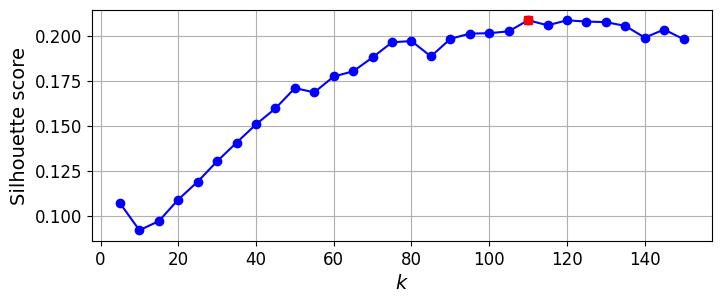

In [45]:
from sklearn.metrics import silhouette_score
silhouette_scores = [silhouette_score(X_train_pca, model.labels_) for model in kmeans_per_k]
best_index = np.argmax(silhouette_scores)
best_k = k_range[best_index] # Esto para pintarlo 
best_score = silhouette_scores[best_index] # equivalente a max(silhouette_scores)
plt.figure(figsize=(8, 3))
plt.plot(k_range, silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
plt.plot(best_k, best_score, "rs")
plt.grid()
plt.show()

In [ ]:
resultado_silueta={}
for k in range(5, 151, 5):
    #Instanciamos el modelo:
    kmeans=KMeans(n_clusters = k,
           random_state = 42,
           n_init=10) #La inicialización es aleatoria
    #Entrenamos el modelo:
    kmeans.fit(X_train_pca)

    #Calculamos el score:
    score=silhouette_score(X_train, kmeans.labels_)

    #Guardamos el resultado en el diccionario:
    resultado_silueta[k]=score
    print(f"K={k}, Silhouette Score={score:.4f}")


K=5, Silhouette Score=0.1053
K=10, Silhouette Score=0.0901
K=15, Silhouette Score=0.0946
K=20, Silhouette Score=0.1059
K=25, Silhouette Score=0.1155
K=30, Silhouette Score=0.1265
K=35, Silhouette Score=0.1363
K=40, Silhouette Score=0.1460
K=45, Silhouette Score=0.1547
K=50, Silhouette Score=0.1652
K=55, Silhouette Score=0.1627
K=60, Silhouette Score=0.1709
K=65, Silhouette Score=0.1731
K=70, Silhouette Score=0.1801
K=75, Silhouette Score=0.1879
K=80, Silhouette Score=0.1884
K=85, Silhouette Score=0.1795
K=90, Silhouette Score=0.1886
K=95, Silhouette Score=0.1912
K=100, Silhouette Score=0.1907
K=105, Silhouette Score=0.1916
K=110, Silhouette Score=0.1969
K=115, Silhouette Score=0.1946
K=120, Silhouette Score=0.1966
K=125, Silhouette Score=0.1956
K=130, Silhouette Score=0.1948
K=135, Silhouette Score=0.1924
K=140, Silhouette Score=0.1859
K=145, Silhouette Score=0.1907
K=150, Silhouette Score=0.1846


In [43]:
#Sacamos el mejor k:
mejor_k = max(resultado_silueta, key=resultado_silueta.get)
print(f"\nEl mejor k es {mejor_k} con un score de {resultado_silueta[mejor_k]:.4f}")


El mejor k es 110 con un score de 0.1969


### #1.7

Repite el ejercio anterior empleando ahora el método del codo de Inercia. ¿Sale algo más concluyente o que refuerce el anterior resultado?

In [46]:
resultado_elbow={}
for k in range(5, 151, 5):
    #Instanciamos el modelo:
    kmeans=KMeans(n_clusters = k,
           random_state = 42,
           n_init=10)
    #Entrenamos el modelo:
    kmeans.fit(X_train_pca)

    #Calculamos el score:
    score=kmeans.inertia_

    #Guardamos el resultado en el diccionario:
    resultado_elbow[k]=score
    print(f"K={k}, Inertia={score:.4f}")

K=5, Inertia=17016.0918
K=10, Inertia=14948.4492
K=15, Inertia=13548.2021
K=20, Inertia=12366.6426
K=25, Inertia=11310.1758
K=30, Inertia=10582.3613
K=35, Inertia=9852.6758
K=40, Inertia=9141.8662
K=45, Inertia=8523.2021
K=50, Inertia=8007.9214
K=55, Inertia=7662.9141
K=60, Inertia=7221.3657
K=65, Inertia=6849.4595
K=70, Inertia=6484.2939
K=75, Inertia=6057.5635
K=80, Inertia=5812.4932
K=85, Inertia=5542.0898
K=90, Inertia=5298.2998
K=95, Inertia=4956.7510
K=100, Inertia=4725.6348
K=105, Inertia=4462.2666
K=110, Inertia=4245.8110
K=115, Inertia=4023.3931
K=120, Inertia=3836.4224
K=125, Inertia=3605.4517
K=130, Inertia=3444.2559
K=135, Inertia=3275.6160
K=140, Inertia=3095.1665
K=145, Inertia=2925.1938
K=150, Inertia=2753.2529


In [47]:
#Sacamos el mejor k:
mejor_k = min(resultado_elbow, key=resultado_elbow.get)
print(f"\nEl mejor k es {mejor_k} con una inercia de {resultado_elbow[mejor_k]:.4f}")


El mejor k es 150 con una inercia de 2753.2529


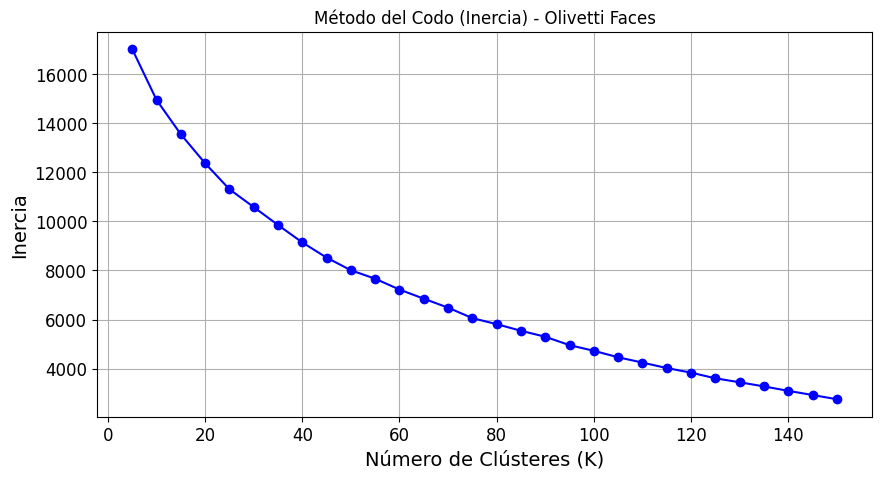

In [48]:
#Dibujamos la Figura
plt.figure(figsize=(10, 5))
plt.plot(list(resultado_elbow.keys()), list(resultado_elbow.values()), marker='o', color='blue')
plt.title('Método del Codo (Inercia) - Olivetti Faces')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

### #1.8

Quédate con el k obtenido con el método del score de silueta y asigna el modelo con ese k a una variable `best_model`

In [49]:
#Mejor k = 140
k_optimo = 120
# Instanciamos el modelo final
best_model = KMeans(
    n_clusters=k_optimo, 
    n_init=10, 
    random_state=42
)

# Entrenamos con el dataset de entrenamiento reducido
best_model.fit(X_train_pca)

print(f"Modelo final entrenado con k={k_optimo}")

Modelo final entrenado con k=120


In [50]:
#Hay 140 etiquetas = fotos
best_model.labels_

array([ 48,  68,  68,  28,  33,  99, 101,  21,  71,  67,  91,  69,  10,
        83,  13,  43, 105,  15,  34,  14,  90,  47,  29,  62,   6,  54,
        33,   8,   0,  48, 103,  38,  73, 110,   7,  84,   7,  88,  15,
        66,  10, 114, 108,  53, 115,  27,   3,  67,   7,  28,  42,  24,
        19,  37,  47,  90, 102,  83,  43,  45,  43,   7, 108,  75,  72,
        18,  73,  32,  35,  79,  11,  44, 113,  20,  35,   3,  13, 100,
        55,  19,  64,   2,  77,  31,  61,  60,  54,  52,  41,  53, 101,
        15,  33,  18,   5,  25,  36,   7,  50,   2,  64,  46,  23,  78,
         1, 109,  46,  11,   2,  82,  99,  37, 107, 111,  68,  87,  11,
        37,  76,  17,  40,   9,  60,  92,  52,   8,   3, 115,  34,  24,
        40,   0,  80,  66,   1,  17,  74,  86,  67,   9,   3, 101, 116,
        66,  70,  57,  11,  58,   3,  89,   4,  42,  19,  19,  44,  17,
         7,  13,  68,  66,  89,  12,  51,  33,  39,  59,  84,  44,  43,
        68,  79,   2,  14,  37,  17,   4,  37, 110,  42,  50,  7

### #1.9

Haz una valoración del método de clustering para el K elegido. Para ello crea un programa que recorra la lista de etiquetas dadas por "best_model" y que, haciendo uso de la función que ya te hemos proporcionado, pinte las caras asignadas a los 10 primeros clústeres. Ojo tendrás que hacer una pequeña adaptación porque las features de entrenamiento no son las features reales (son una "transformación" de estas) y si pasas el X de entrenamiento no verás nada. ¿Ves caras similares?

Cluster 0


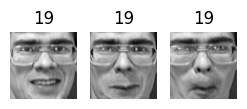

Cluster 1


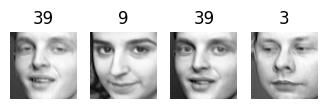

Cluster 2


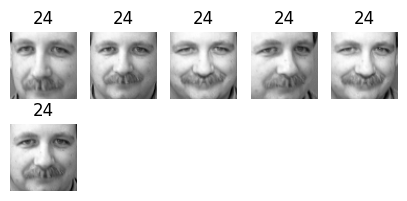

Cluster 3


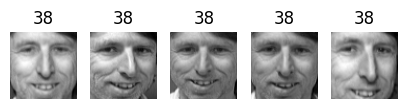

Cluster 4


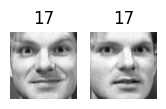

Cluster 5


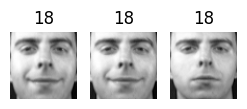

Cluster 6


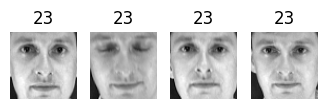

Cluster 7


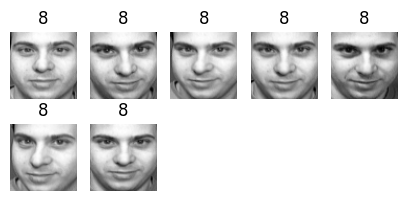

Cluster 8


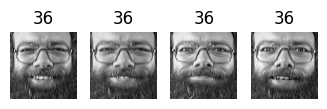

Cluster 9


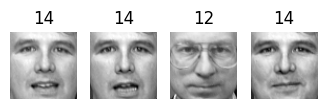

Cluster 10


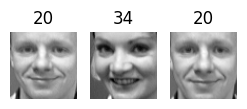

Cluster 11


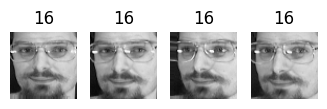

Cluster 12


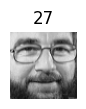

Cluster 13


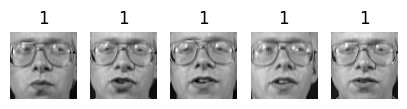

Cluster 14


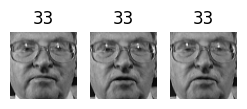

Cluster 15


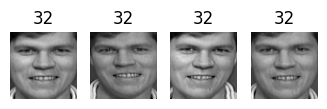

Cluster 16


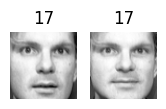

Cluster 17


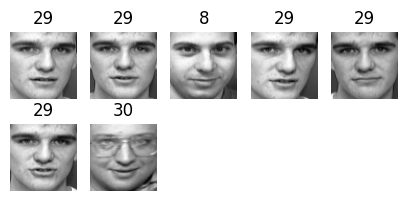

Cluster 18


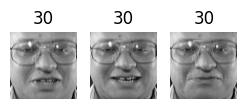

Cluster 19


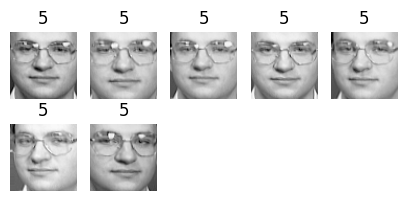

Cluster 20


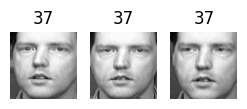

Cluster 21


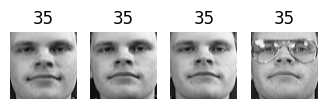

Cluster 22


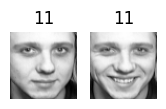

Cluster 23


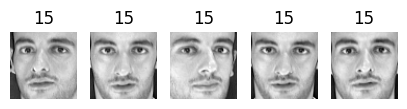

Cluster 24


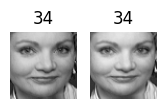

Cluster 25


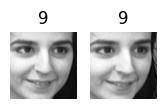

Cluster 26


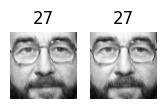

Cluster 27


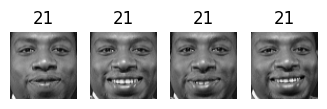

Cluster 28


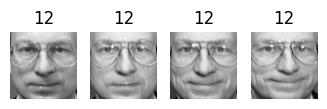

Cluster 29


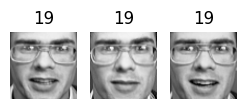

In [51]:
for cluster_id in np.unique(best_model.labels_)[0:30]:
    print("Cluster", cluster_id)
    in_cluster = best_model.labels_==cluster_id
    faces = X_train[in_cluster].values
    labels = y_train[in_cluster]
    plot_faces(faces, labels)


--- VISUALIZANDO EL CLÚSTER NÚMERO 0 ---
Número de caras encontradas en este grupo: 3


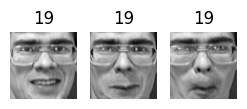


--- VISUALIZANDO EL CLÚSTER NÚMERO 1 ---
Número de caras encontradas en este grupo: 4


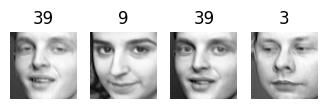


--- VISUALIZANDO EL CLÚSTER NÚMERO 2 ---
Número de caras encontradas en este grupo: 6


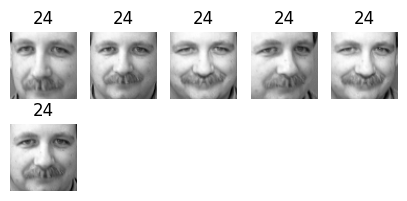


--- VISUALIZANDO EL CLÚSTER NÚMERO 3 ---
Número de caras encontradas en este grupo: 5


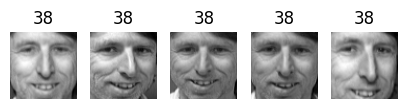


--- VISUALIZANDO EL CLÚSTER NÚMERO 4 ---
Número de caras encontradas en este grupo: 2


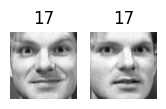


--- VISUALIZANDO EL CLÚSTER NÚMERO 5 ---
Número de caras encontradas en este grupo: 3


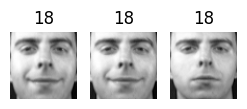


--- VISUALIZANDO EL CLÚSTER NÚMERO 6 ---
Número de caras encontradas en este grupo: 4


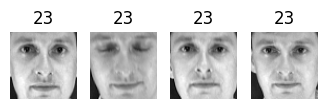


--- VISUALIZANDO EL CLÚSTER NÚMERO 7 ---
Número de caras encontradas en este grupo: 7


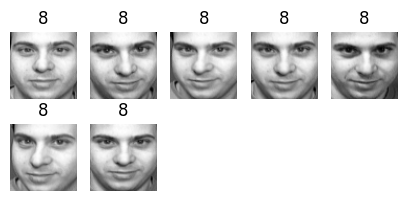


--- VISUALIZANDO EL CLÚSTER NÚMERO 8 ---
Número de caras encontradas en este grupo: 4


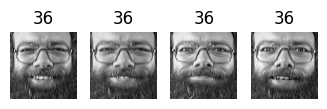


--- VISUALIZANDO EL CLÚSTER NÚMERO 9 ---
Número de caras encontradas en este grupo: 4


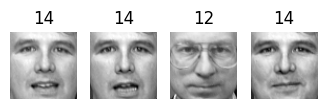

In [52]:
#Nota: Hay que utilizar X_train (no está reducido)
labels_clusters = best_model.labels_
for cluster_id in range(10):
    # Buscamos los índices de las caras que pertenecen a este clúster
    indices = np.where(labels_clusters == cluster_id)[0]
    
    # Extraemos las imágenes originales (X_train) y sus etiquetas reales (y_train)
    # Usamos .iloc para filtrar las filas de los DataFrames de pandas
    caras_del_cluster = X_train.iloc[indices]
    nombres_reales = y_train.iloc[indices]
    
    print(f"\n--- VISUALIZANDO EL CLÚSTER NÚMERO {cluster_id} ---")
    print(f"Número de caras encontradas en este grupo: {len(caras_del_cluster)}")
    
    # 3. Adaptación para pintar: Usamos la función plot_faces
    # Pasamos las caras originales (píxeles) para que se puedan ver
    if len(caras_del_cluster) > 0:
        plot_faces(caras_del_cluster.values, nombres_reales)
    else:
        print("Este clúster está vacío.")

## **#2**


### #2.1


Continuando con el conjunto de datos de caras Olivetti, entrena un clasificador para predecir qué persona está representada en cada imagen, y evalúalo en el conjunto de validación. Utiliza un RandomForest con 150 submodelos o estimadores (y el resto de hiperparámetros déjalos a su valor por defecto)

In [53]:
len(X_train_pca)

320

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Instanciar el modelo con 150 estimadores
rf_clf = RandomForestClassifier(n_estimators=150, random_state=42)

# 2. Entrenar el modelo con los datos de entrenamiento (PCA)
rf_clf.fit(X_train_pca, y_train)

# 3. Realizar predicciones sobre el conjunto de VALIDACIÓN (PCA)
y_pred_val = rf_clf.predict(X_valid_pca)

In [55]:
# Calcular el accuracy
accuracy = accuracy_score(y_val, y_pred_val)

print(f"Accuracy en el conjunto de validación: {accuracy:.4f}")

# Mostrar el informe de clasificación (opcional pero muy útil)
# Nota: Como hay 40 personas, el informe será largo.
# print(classification_report(y_val, y_pred_val))

Accuracy en el conjunto de validación: 0.9250


### #2.2

Utiliza K-Means como una herramienta de reducción de dimensionalidad y entrena un clasificador en el conjunto reducido. Para ello emplea el método transform de manera que ahora las features de entrada sean las distancias de cada punto a los centroides del modelo "best_model" de la parte anterior. Por ejemplo:
```python
X_train_reduced = best_model.transform(X_train_pca) 
```


Ojo lo tienes que aplicar a todos los datasets. Luego vuelve a entrenar un RandomForest sobre este dataset y evalualo contra el dataset de validacion.

In [65]:
len(best_model.cluster_centers_)

120

In [64]:
#La PCA puede hacer la inversa
plt.imshow(pca.inverse_transform(best_model.cluster_centers_[0]).reshape(64,64), cmap="Greys_r")


ValueError: Expected 2D array, got 1D array instead:
array=[-3.68777561e+00  1.71494210e+00 -2.24365211e+00  1.08943176e+00
 -6.03824794e-01  7.55051255e-01  1.54877591e+00  1.70035350e+00
 -2.04152918e+00  1.21393931e+00 -2.23514891e+00  2.63035506e-01
 -3.06548238e-01 -9.49465573e-01 -1.22987330e+00  3.66237806e-03
 -8.13416205e-03 -4.54897344e-01 -1.43954599e+00  6.92372322e-01
 -8.76039565e-01 -8.65791321e-01  6.36781529e-02  5.32753468e-01
 -6.73098266e-01  1.06690839e-01  4.73112583e-01  5.47769189e-01
 -4.99110013e-01  3.64160240e-01 -9.36341584e-01 -1.46438509e-01
  5.07562980e-03  7.47547090e-01  4.40058231e-01 -8.01082887e-03
 -2.22286001e-01 -8.39910135e-02  6.97094083e-01 -9.58250314e-02
 -2.01747626e-01  1.82547450e-01  8.03003833e-02  7.00907037e-02
 -2.77342498e-01  8.05796325e-01  2.86646575e-01 -1.34545058e-01
  9.26338136e-02  4.30574179e-01 -2.36900985e-01  3.58722180e-01
  5.12674928e-01  9.39755738e-02 -4.52326626e-01 -3.24360222e-01
  4.42870110e-01  4.83400345e-0

In [66]:
#No siempre ayuda una reducción de la dimensionaldiad

### #2.3 EXTRA VOLUNTARIO

Busca el número de clusters k que generen un algoritmo kmeans que a su vez sus distancias a los centroides sean las features de un clasificador RandomForest y que permita al clasificador obtener el mejor rendimiento: ¿Qué rendimiento puedes alcanzar? (en terminos de Accuracy)